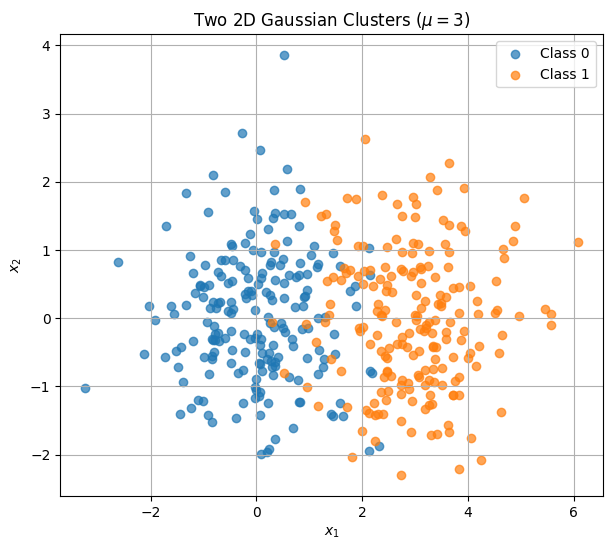

In [3]:
# Problem 1: Generate the data

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

np.random.seed(42)

mu = 3
n_per_class = 200

# Class 0: x0 ~ N((0,0), I)
X0 = np.random.multivariate_normal(mean=[0, 0],
                                   cov=[[1, 0], [0, 1]],
                                   size=n_per_class)

# Class 1: x1 ~ N((mu,0), I)
X1 = np.random.multivariate_normal(mean=[mu, 0],
                                   cov=[[1, 0], [0, 1]],
                                   size=n_per_class)

# Combine data
X = np.vstack([X0, X1])
y = np.hstack([np.zeros(n_per_class), np.ones(n_per_class)])

# Plot the generated data
plt.figure(figsize=(7, 6))
plt.scatter(X0[:, 0], X0[:, 1], label='Class 0', alpha=0.7)
plt.scatter(X1[:, 0], X1[:, 1], label='Class 1', alpha=0.7)
plt.xlabel(r'$x_1$')
plt.ylabel(r'$x_2$')
plt.title(r'Two 2D Gaussian Clusters ($\mu = 3$)')
plt.legend()
plt.grid(True)
plt.show()



/Users/hani/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/hani/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/hani/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


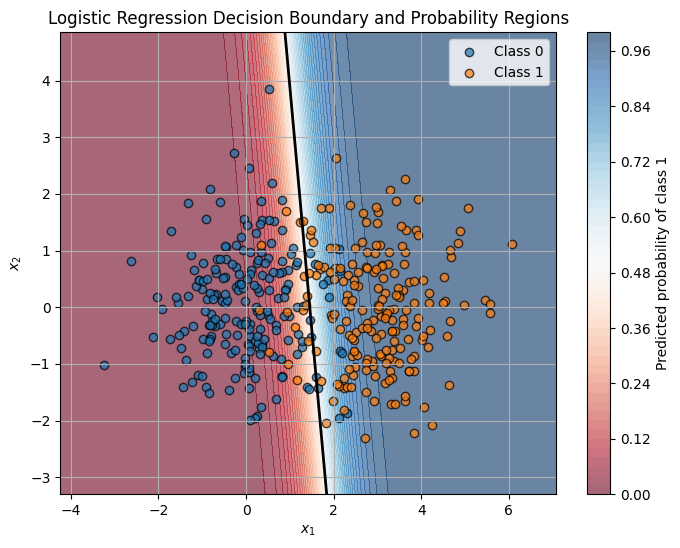

Intercept: -4.03483511757271
Coefficients: [2.77256142 0.32408973]


In [2]:
# Problem 2: Logistic Regression

model = LogisticRegression()
model.fit(X, y)

# Create a grid for probability shading
x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 300),
                       np.linspace(x2_min, x2_max, 300))

grid = np.c_[xx1.ravel(), xx2.ravel()]

# Predicted probability for class 1
proba = model.predict_proba(grid)[:, 1].reshape(xx1.shape)

# Plot probability regions + decision boundary + data
plt.figure(figsize=(8, 6))

# Shade probability regions
contour = plt.contourf(xx1, xx2, proba, levels=50, alpha=0.6, cmap='RdBu')

# Decision boundary: P(y=1|x)=0.5
plt.contour(xx1, xx2, proba, levels=[0.5], colors='black', linewidths=2)

# Plot data points
plt.scatter(X0[:, 0], X0[:, 1], label='Class 0', edgecolor='k', alpha=0.7)
plt.scatter(X1[:, 0], X1[:, 1], label='Class 1', edgecolor='k', alpha=0.7)

plt.xlabel(r'$x_1$')
plt.ylabel(r'$x_2$')
plt.title('Logistic Regression Decision Boundary and Probability Regions')
plt.legend()
plt.colorbar(contour, label=r'Predicted probability of class 1')
plt.grid(True)
plt.show()

# Print model parameters
print("Intercept:", model.intercept_[0])
print("Coefficients:", model.coef_[0])

## Problem 3: Performance vs Separation

We repeat the experiment for different separations between the Gaussian clusters $\mu = 3,\;2,\;1,\;0.5$

The two classes are generated as $\mathbf{x}_0 \sim \mathcal{N}((0,0), I)$ \& $\mathbf{x}_1 \sim \mathcal{N}((\mu,0), I)$
where I is the identity covariance matrix.

As $ \mu $ decreases, the distance between the two Gaussian means becomes smaller.  
This increases the overlap between the class distributions and makes the classification problem more difficult.

For each value of $ \mu $, we evaluate the classifier using the following metrics.

$$
Accuracy = \frac{TP + TN}{TP + TN + FP + FN}
$$

$$
FPR = \frac{FP}{FP + TN}
$$

$$
FNR = \frac{FN}{FN + TP}
$$

where TP = True Positives, TN = True Negatives, FP = False Positives, FN = False Negatives.

mu	 accuracy 	 fpr 		 fnr
3	0.935		0.060		0.070
2	0.838		0.165		0.160
1	0.688		0.315		0.310
0.5	0.555		0.455		0.435


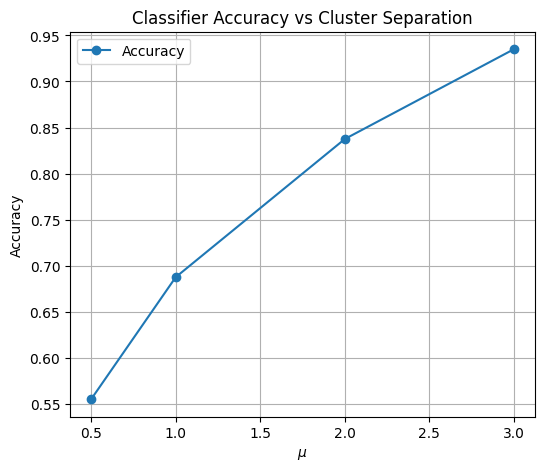

In [3]:
# Problem 3

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

np.random.seed(42)

mus = [3,2,1,0.5]
n = 200

accuracy_list = []
fpr_list = []
fnr_list = []

print('mu\t accuracy \t fpr \t\t fnr')
for mu in mus:
    
    # generate data
    X0 = np.random.multivariate_normal([0,0], [[1,0],[0,1]], n)
    X1 = np.random.multivariate_normal([mu,0], [[1,0],[0,1]], n)
    
    X = np.vstack((X0,X1))
    y = np.hstack((np.zeros(n),np.ones(n)))
    
    # train classifier
    model = LogisticRegression()
    model.fit(X,y)
    
    y_pred = model.predict(X)
    
    # confusion matrix
    tn, fp, fn, tp = confusion_matrix(y,y_pred).ravel()
    
    accuracy = (tp+tn)/(tp+tn+fp+fn)
    fpr = fp/(fp+tn)
    fnr = fn/(fn+tp)
    
    accuracy_list.append(accuracy)
    fpr_list.append(fpr)
    fnr_list.append(fnr)

    print(f"{mu}\t{accuracy:.3f}\t\t{fpr:.3f}\t\t{fnr:.3f}")
    
plt.figure(figsize=(6,5))

plt.plot(mus,accuracy_list,'o-',label='Accuracy')
plt.xlabel(r'$\mu$')
plt.ylabel('Accuracy')
plt.title('Classifier Accuracy vs Cluster Separation')
plt.grid()
plt.legend()

plt.show()

# Problem 4: Interpretation

**1. Why does performance degrade as $ \mu \to 0 $?**

As $ \mu $ decreases, the means of the two Gaussian distributions move closer together.  
When the centers are close, the distributions overlap more strongly, so samples from the two classes become harder to distinguish.  
Because of this overlap, the classifier cannot reliably separate the classes, which increases both false positives and false negatives and reduces overall accuracy.

---

**2. Does adding more data help when $ \mu = 0 $?**

No. When $ \mu = 0 $, both classes are drawn from the same distribution:

$$
\mathcal{N}((0,0), I)
$$

Since the data distributions are identical, there is no information in the features that distinguishes the classes.  
Adding more data only provides more samples from the same distribution and does not improve classification performance.

---

**3. What assumption does a linear classifier make about the data?**

A linear classifier assumes that the classes can be separated by a linear decision boundary:

$$
w_1 x_1 + w_2 x_2 + b = 0
$$

This means the model assumes that the relationship between the features and the class labels can be captured by a straight line (or hyperplane in higher dimensions).  
If the true class structure is not linearly separable, the classifier may perform poorly.